In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
import lightgbm as lgb
import seaborn as sns
# Suppress LightGBM warnings
logging.getLogger('lightgbm').setLevel(logging.ERROR)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import optuna

import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.correlations import *
from utilities.explanation import *
from utilities.for_ploting import *
from utilities.imputation import *
from utilities.modelling import *
from utilities.preprocessing import *
from utilities.cleaning import *

In [3]:
print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('tested.csv')
train = train_df.copy()
test= test_df.copy()

Loading data...


## EDA

In [4]:
display_basic_info(train_df)


 Number of Rows and Columns:
 (891, 12)

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Number of Unique Values:
 PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket     

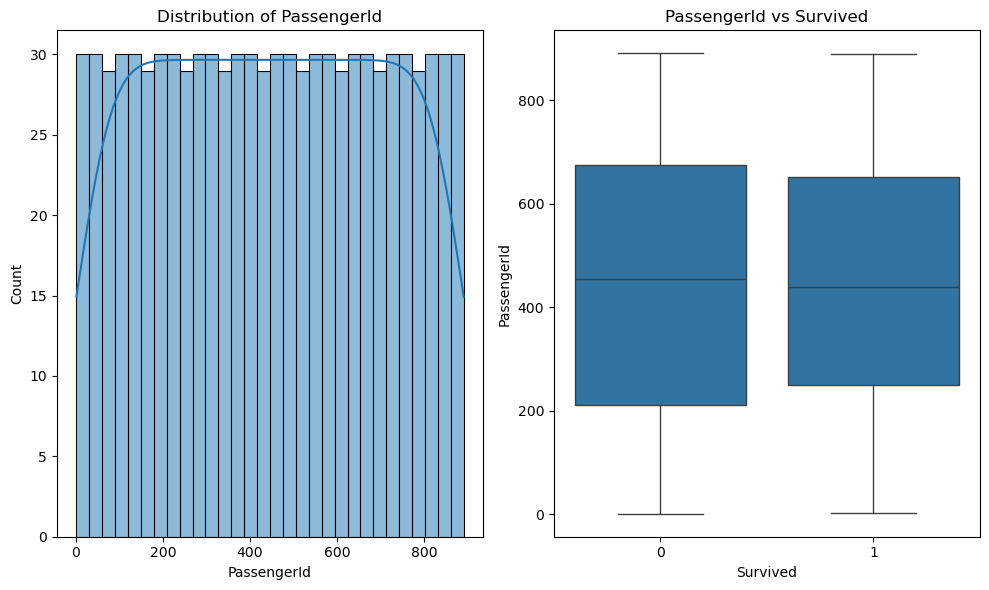

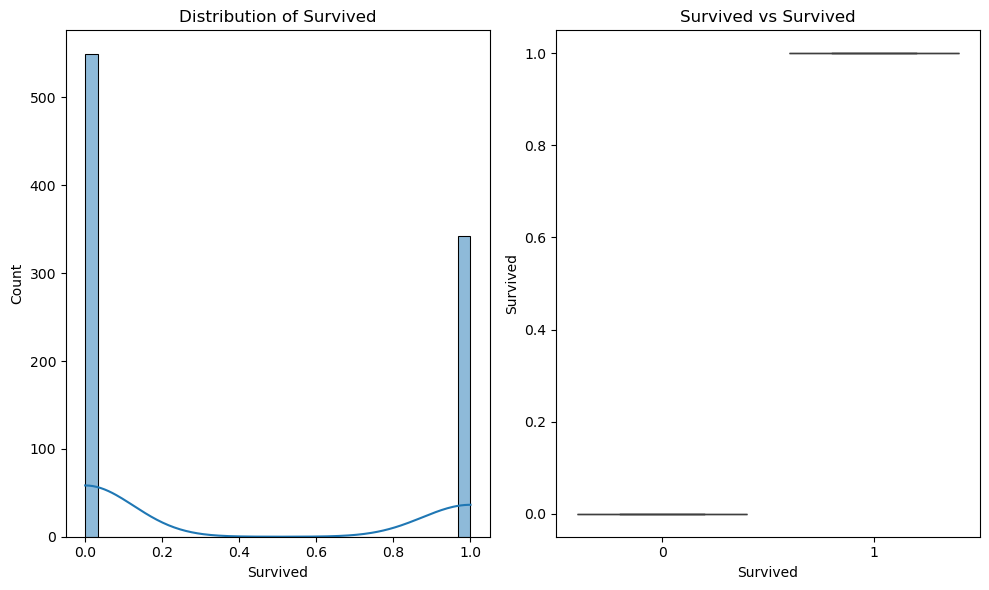

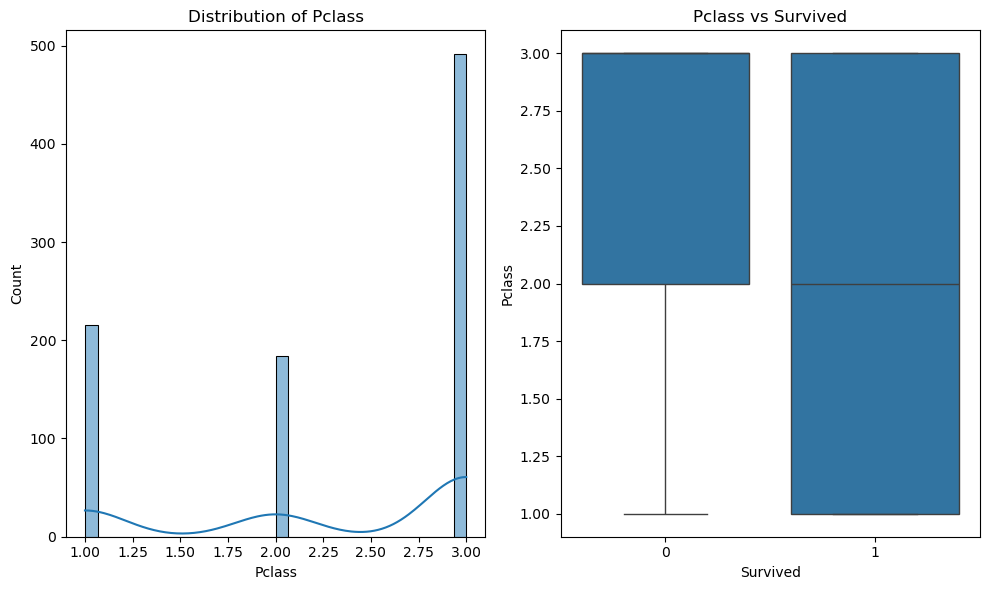

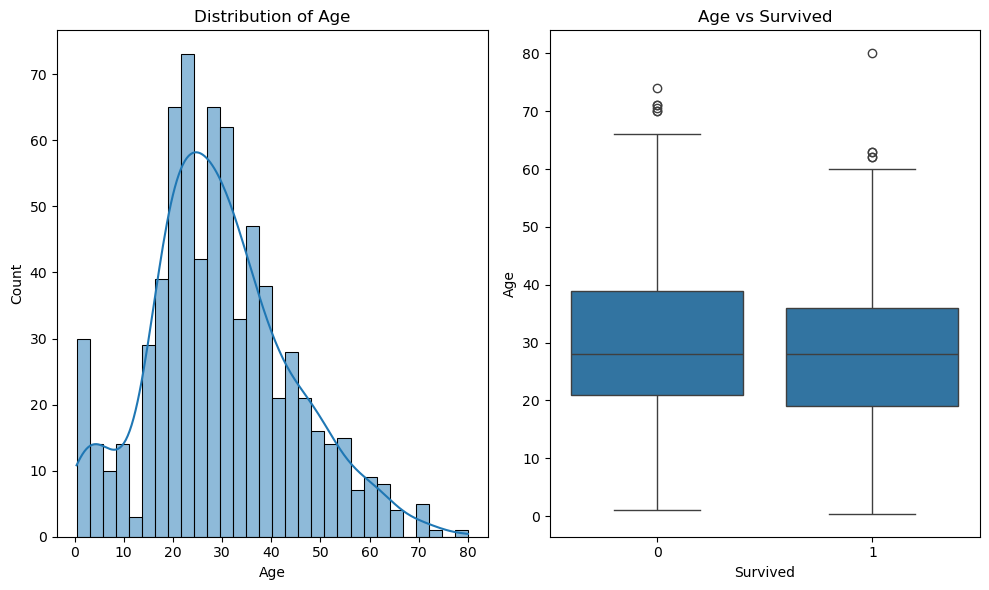

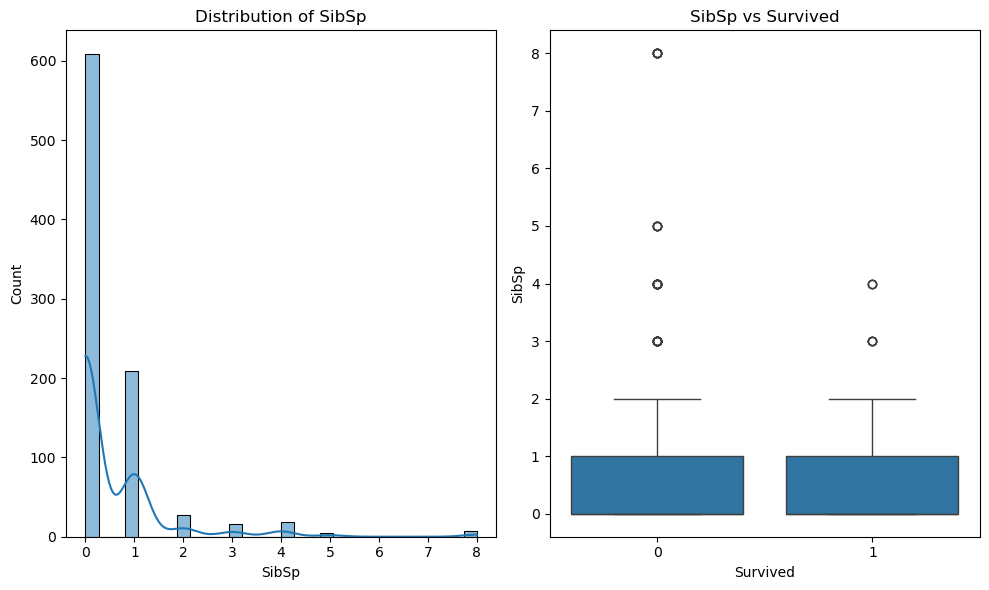

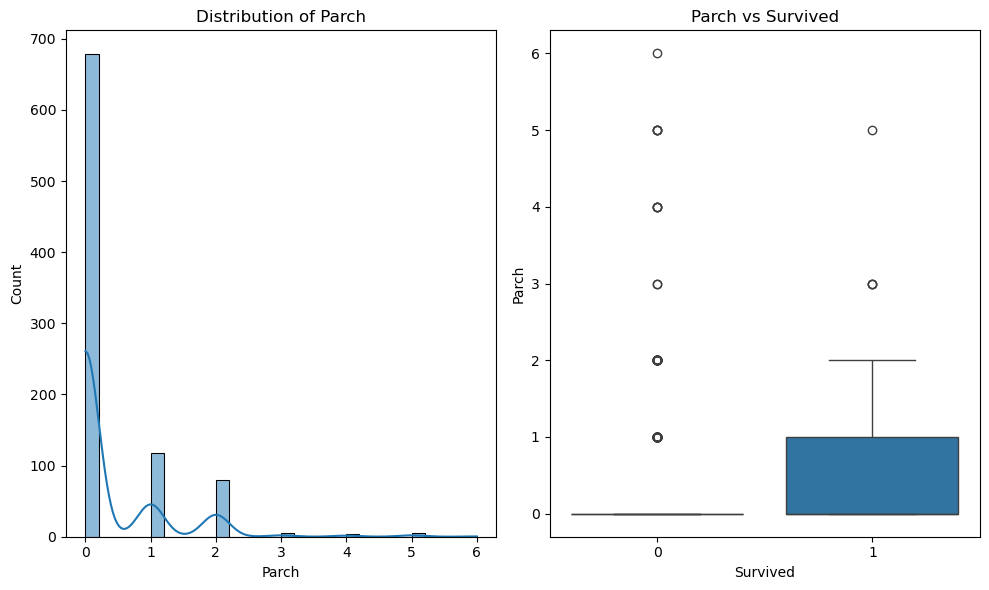

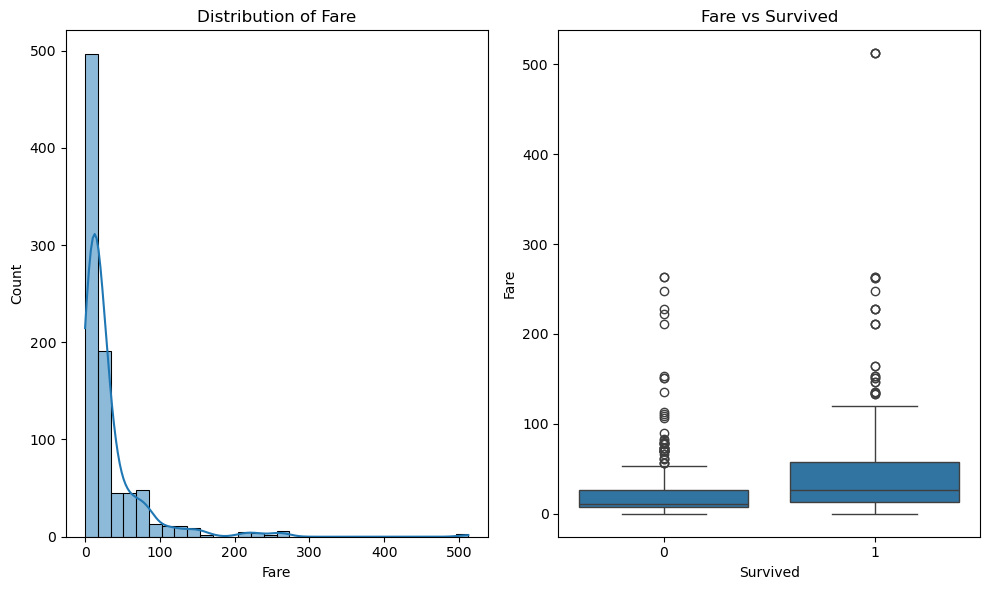

In [5]:
target = 'Survived'
exclude_cols = ['PassengerId', 'Survived']
plot_all_num_vs_target(train_df, target)

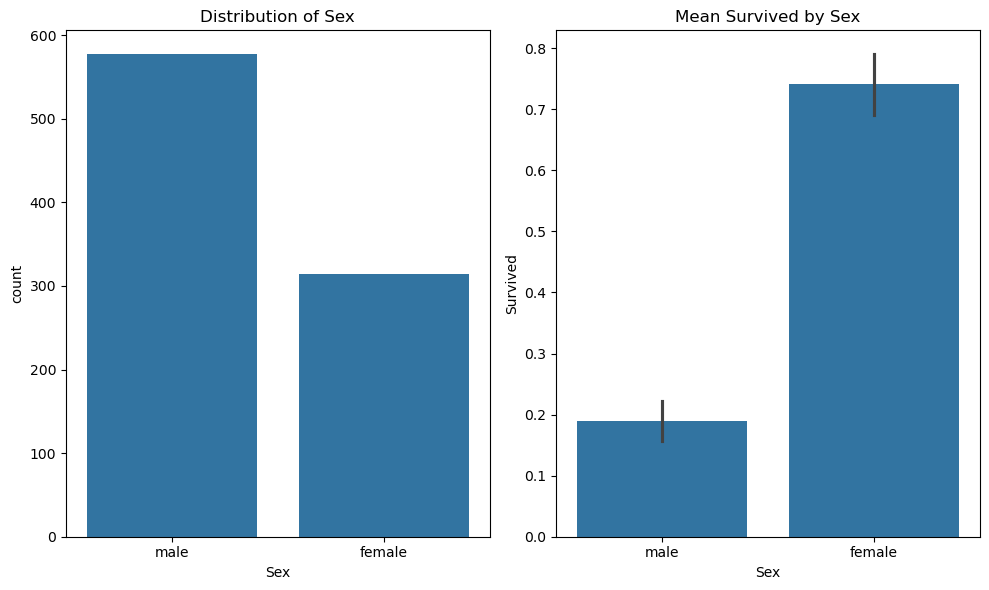

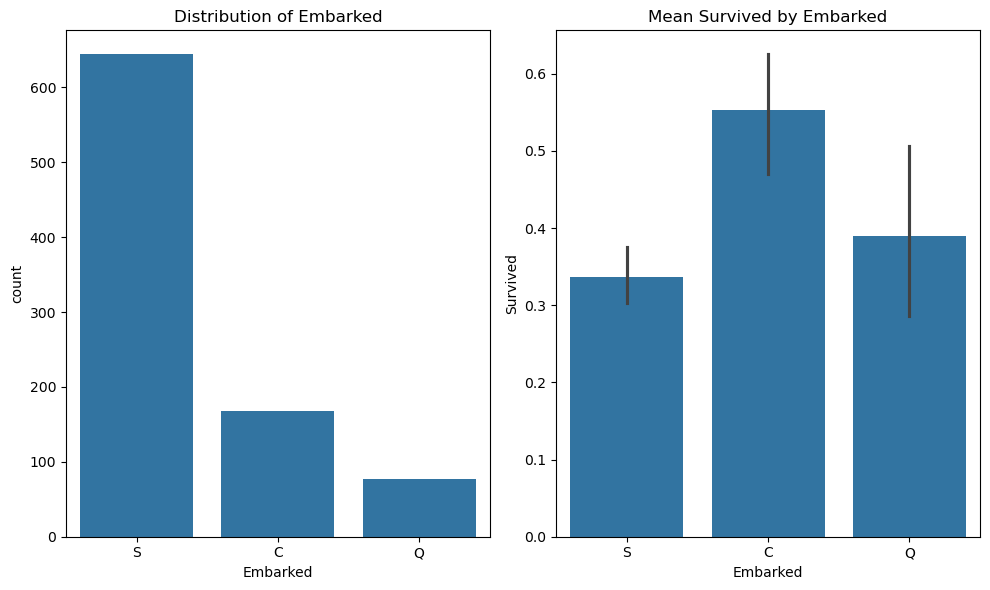

In [6]:
plot_all_cat_vs_target(train_df, target,exclude_cols=['Name','Ticket','Cabin','set'])

## Combinatorial Feature Analysis

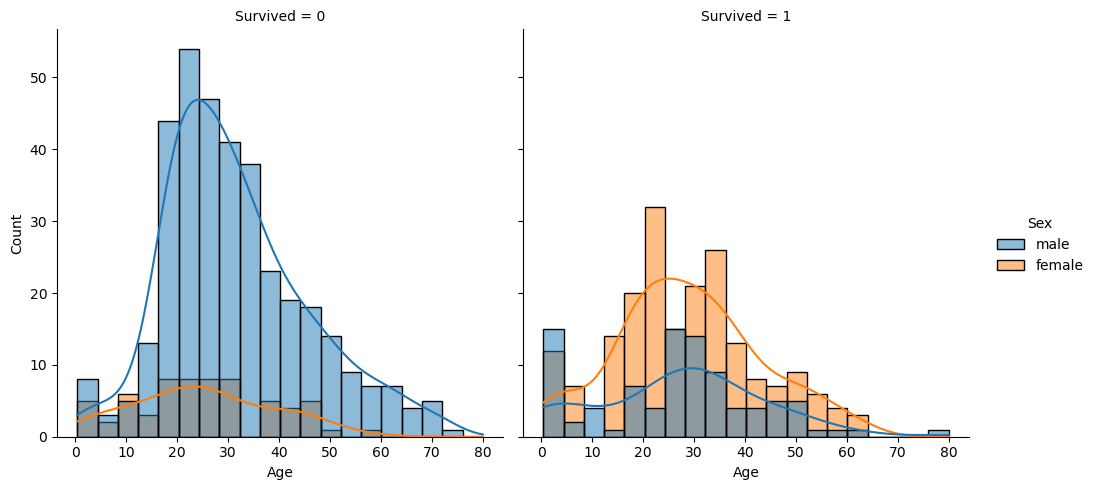

In [7]:
plot_one_num_two_cat(train_df,'Age','Sex','Survived')

<Figure size 800x500 with 0 Axes>

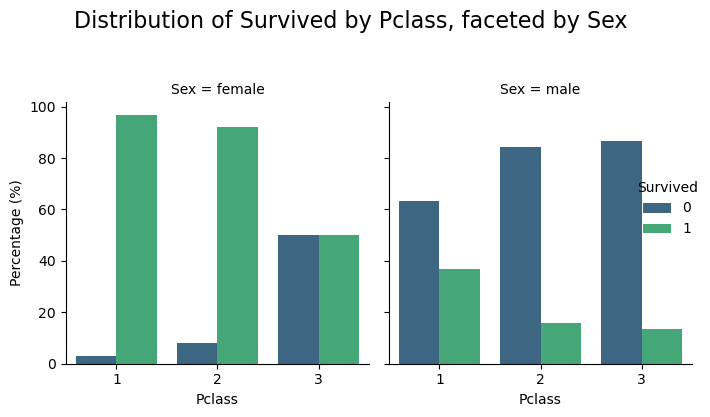

In [8]:
plot_three_categorical_correlation(train_df, 'Sex', 'Pclass', target)
plt.show()

In [9]:
train_df['set'] = 'train'
test_df['set'] = 'test'
all_df = pd.concat([train_df, test_df], axis=0)

In [10]:
#https://github.com/PacktPublishing/Developing-Kaggle-Notebooks/blob/main/Chapter-03/titanic-start-of-a-journey-around-data-world.ipynb

all_df["Family Size"] = all_df["SibSp"] + all_df["Parch"] + 1
all_df["Age Interval"] = 0.0
all_df.loc[ all_df['Age'] <= 16, 'Age Interval']  = 0
all_df.loc[(all_df['Age'] > 16) & (all_df['Age'] <= 32), 'Age Interval'] = 1
all_df.loc[(all_df['Age'] > 32) & (all_df['Age'] <= 48), 'Age Interval'] = 2
all_df.loc[(all_df['Age'] > 48) & (all_df['Age'] <= 64), 'Age Interval'] = 3
all_df.loc[ all_df['Age'] > 64, 'Age Interval'] = 4
all_df['Fare Interval'] = 0.0
all_df.loc[ all_df['Fare'] <= 7.91, 'Fare Interval'] = 0
all_df.loc[(all_df['Fare'] > 7.91) & (all_df['Fare'] <= 14.454), 'Fare Interval'] = 1
all_df.loc[(all_df['Fare'] > 14.454) & (all_df['Fare'] <= 31), 'Fare Interval']   = 2
all_df.loc[ all_df['Fare'] > 31, 'Fare Interval'] = 3
all_df["Sex_Pclass"] = all_df.apply(lambda row: row['Sex'][0].upper() + "_C" + str(row["Pclass"]), axis=1)
def get_deck(text):
    try:
        return text[0]
    except Exception as ex:
        return "Unknown"
    
all_df["Deck"] = all_df["Cabin"].apply(lambda x: get_deck(x))

<Axes: xlabel='Survived', ylabel='Family Size'>

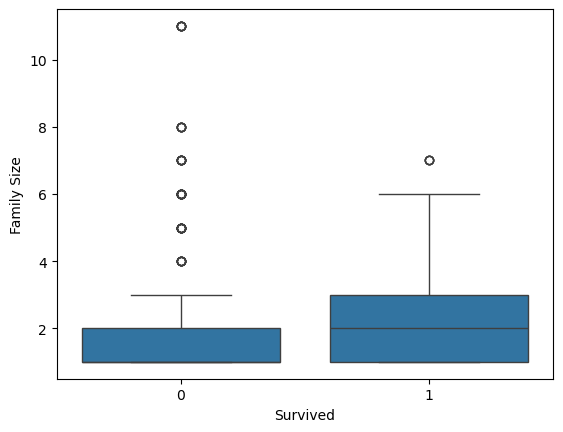

In [11]:
sns.boxplot(x='Survived',y="Family Size",data=all_df[all_df['set']=='train'])

In [12]:
#https://github.com/PacktPublishing/Developing-Kaggle-Notebooks/blob/main/Chapter-03/titanic-start-of-a-journey-around-data-world.ipynb

def parse_names(row):
    try:
        text = row["Name"]
        split_text = text.split(",")
        family_name = split_text[0]
        next_text = split_text[1]
        split_text = next_text.split(".")
        title = (split_text[0] + ".").lstrip().rstrip()
        next_text = split_text[1]
        if "(" in next_text:
            split_text = next_text.split("(")
            given_name = split_text[0]
            maiden_name = split_text[1].rstrip(")")
            return pd.Series([family_name, title, given_name, maiden_name])
        else:
            given_name = next_text
            return pd.Series([family_name, title, given_name, None])
    except Exception as ex:
        print(f"Exception: {ex}")
    
all_df[["Family Name", "Title", "Given Name", "Maiden Name"]] = all_df.apply(lambda row: parse_names(row), axis=1)

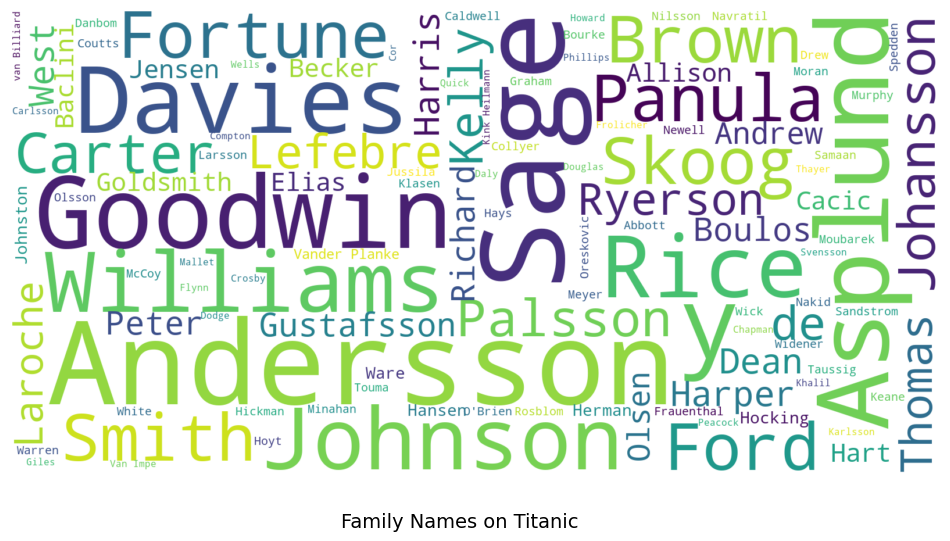

In [13]:
#https://github.com/PacktPublishing/Developing-Kaggle-Notebooks/blob/main/Chapter-03/titanic-start-of-a-journey-around-data-world.ipynb

from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data, mask=None, title=""):
    text = " ".join(t for t in data.dropna())
    stopwords = set(STOPWORDS)
    stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
    wordcloud = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=500,mask=mask, background_color="white").generate(text)
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.show()    
show_wordcloud(all_df["Family Name"], title="Family Names on Titanic")

In [14]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,set,Family Size,Age Interval,Fare Interval,Sex_Pclass,Deck,Family Name,Title,Given Name,Maiden Name
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,train,2,1.0,0.0,M_C3,Unknown,Braund,Mr.,Owen Harris,None
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,train,2,2.0,3.0,F_C1,C,Cumings,Mrs.,John Bradley,Florence Briggs Thayer
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,train,1,1.0,1.0,F_C3,Unknown,Heikkinen,Miss.,Laina,None
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,train,2,2.0,3.0,F_C1,C,Futrelle,Mrs.,Jacques Heath,Lily May Peel
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,train,1,2.0,1.0,M_C3,Unknown,Allen,Mr.,William Henry,None


In [15]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    1309 non-null   int64  
 1   Survived       1309 non-null   int64  
 2   Pclass         1309 non-null   int64  
 3   Name           1309 non-null   object 
 4   Sex            1309 non-null   object 
 5   Age            1046 non-null   float64
 6   SibSp          1309 non-null   int64  
 7   Parch          1309 non-null   int64  
 8   Ticket         1309 non-null   object 
 9   Fare           1308 non-null   float64
 10  Cabin          295 non-null    object 
 11  Embarked       1307 non-null   object 
 12  set            1309 non-null   object 
 13  Family Size    1309 non-null   int64  
 14  Age Interval   1309 non-null   float64
 15  Fare Interval  1309 non-null   float64
 16  Sex_Pclass     1309 non-null   object 
 17  Deck           1309 non-null   object 
 18  Family Name   

In [16]:
# Print number of unique values in each column
print("\nUnique values in each column:")
print(all_df.nunique())


Unique values in each column:
PassengerId      1309
Survived            2
Pclass              3
Name             1307
Sex                 2
Age                98
SibSp               7
Parch               8
Ticket            929
Fare              281
Cabin             186
Embarked            3
set                 2
Family Size         9
Age Interval        5
Fare Interval       4
Sex_Pclass          6
Deck                9
Family Name       875
Title              18
Given Name       1083
Maiden Name       220
dtype: int64


In [17]:
print(all_df.isnull().sum())

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               263
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin            1014
Embarked            2
set                 0
Family Size         0
Age Interval        0
Fare Interval       0
Sex_Pclass          0
Deck                0
Family Name         0
Title               0
Given Name          0
Maiden Name      1088
dtype: int64


In [18]:
all_df["Age"].fillna(all_df["Age"].median(), inplace=True)
all_df["Maiden Name"].fillna("Unknown", inplace=True)
all_df["Cabin"].fillna("Unknown", inplace=True)

In [19]:
#Columns with unique values that are more than 200

unique_counts = all_df.nunique()
unique_columns = unique_counts[unique_counts > 200].index.tolist()
dropped_all_df = all_df.drop(columns=unique_columns + ["set", "Survived"])

cat_columns = dropped_all_df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_columns:
    dropped_all_df[col] = dropped_all_df[col].astype('category')

In [20]:

X_train = dropped_all_df[all_df["set"] == "train"]
X_test = dropped_all_df[all_df["set"] == "test"]
y_train = all_df[all_df["set"] == "train"]["Survived"]
y_test = all_df[all_df["set"] == "test"]["Survived"]





Class unbalanced: True
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 307, number of negative: 494
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.742821
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.365889
[LightGBM] [Debug] init for col-wise cost 0.000204 seconds, init for row-wise cost 0.000290 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 139
[LightGBM] [Info] Number of data points in the train set: 801, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383271 -> initscore=-0.475688
[LightGBM] [Info]

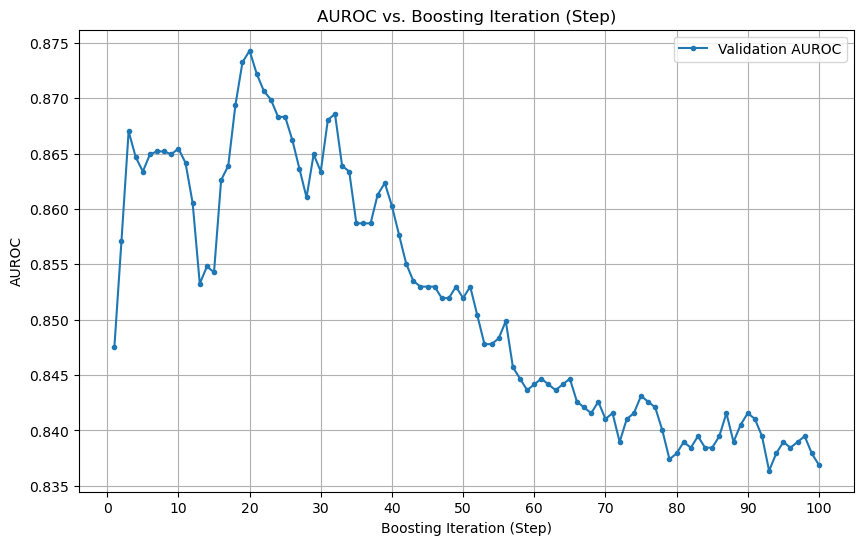


Best Iteration (based on validation AUROC): 20
Best Validation AUROC: 0.8743


In [21]:
model = training_binary_classification_with_lgbm(X_train, y_train, split=0.1)


In [22]:
print(f"test score of LightGBM: {model.score(X_test, y_test)}")

test score of LightGBM: 0.8875598086124402


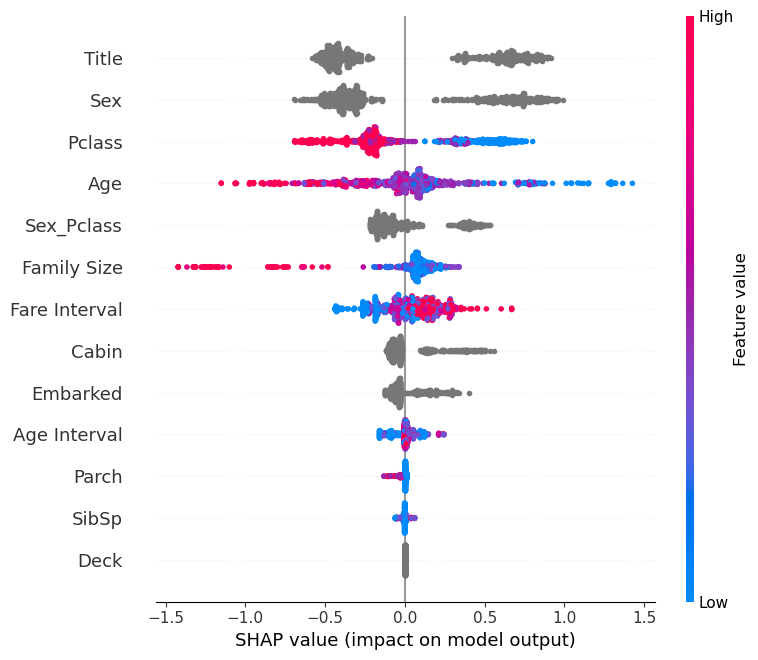

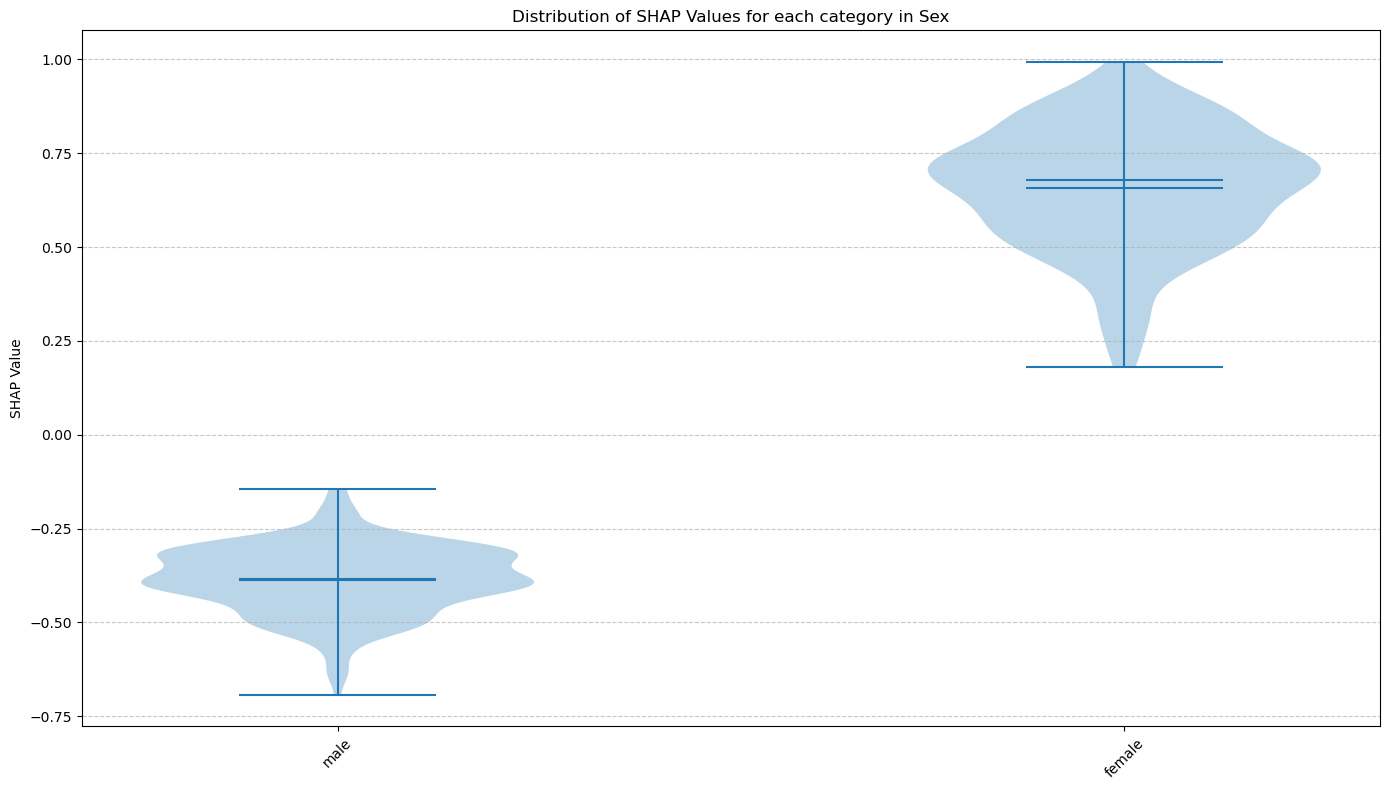

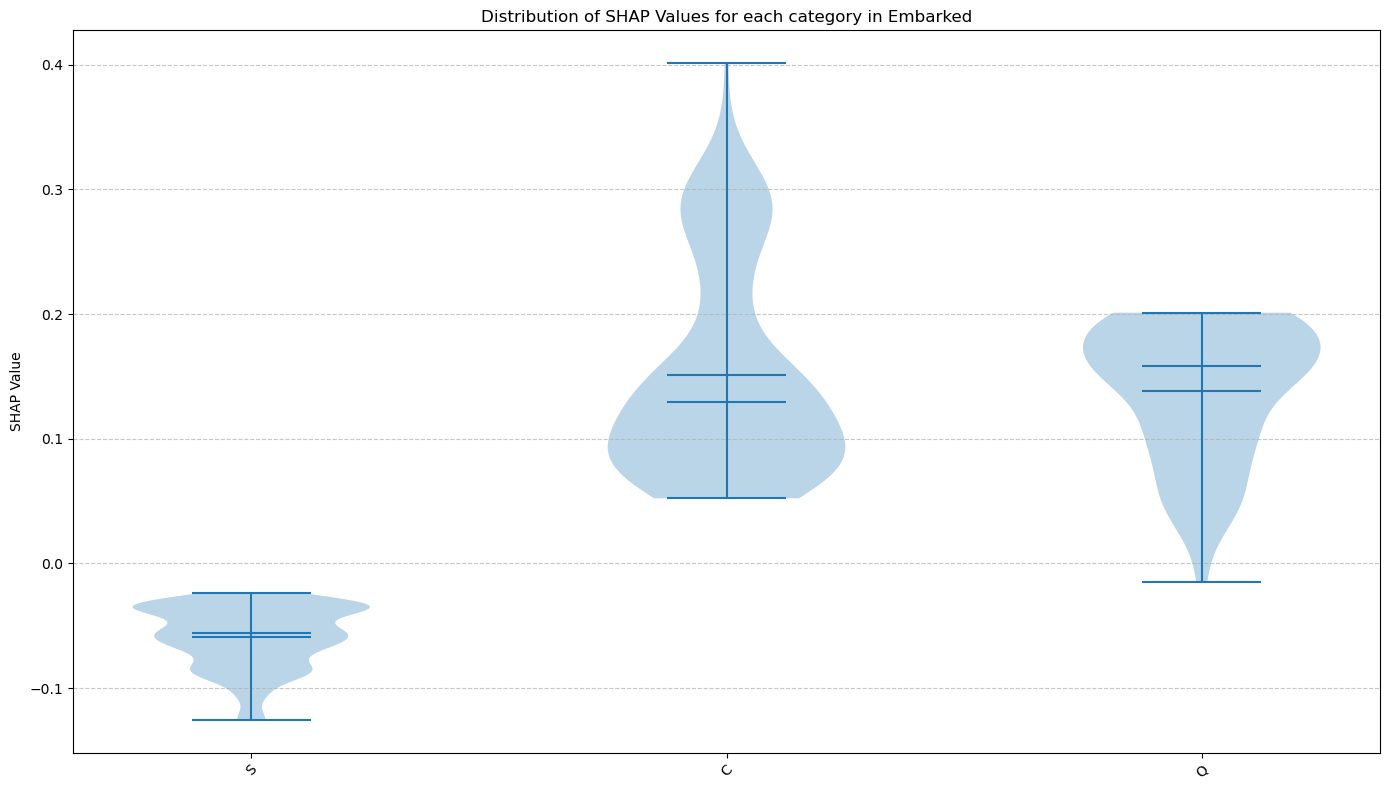

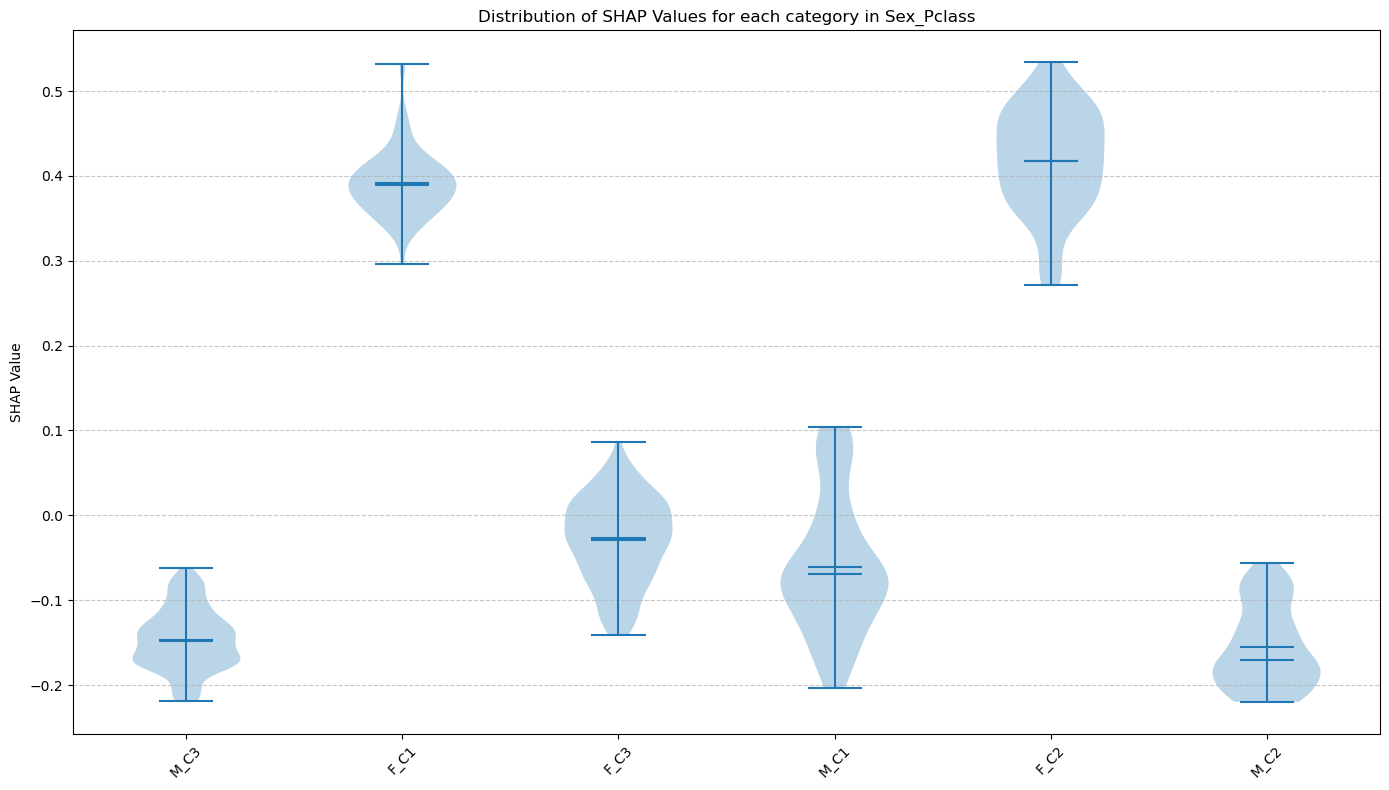

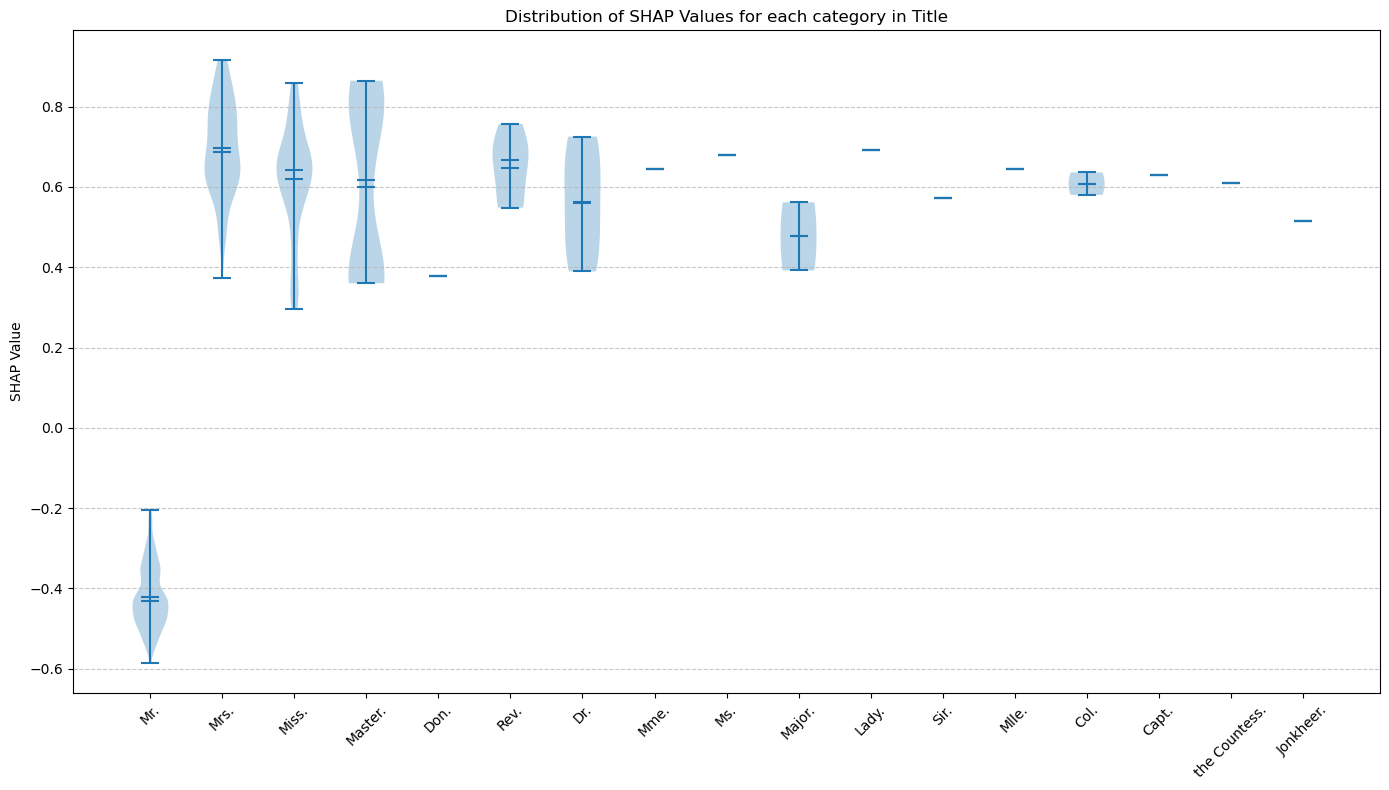

In [23]:
features = X_train.columns.tolist()
shap_explain_model_on_batch(model, X_train, features,excluded_cat_features=['Cabin','Deck'])

In [24]:
#! pip install git+https://github.com/milesqli/iffnn.git 

# Explanation With My IFFNN

In [25]:
import torch
from iffnn import IFFNN


In [26]:

dummy_all_df = pd.get_dummies(dropped_all_df, columns=cat_columns, drop_first=True)
X_train = dummy_all_df[all_df["set"] == "train"]
X_test = dummy_all_df[all_df["set"] == "test"]
y_train = all_df[all_df["set"] == "train"]["Survived"]
y_test = all_df[all_df["set"] == "test"]["Survived"]



model = IFFNN(
    input_size=len(X_train.columns),
    num_classes=1,
    feature_names=X_train.columns.tolist(),  # Optional
    class_names=['Not Survived', 'Survived'],      # Optional
    hidden_sizes=[226, 113, 113,113,226], #None,            # Use default hidden layers
    device='auto'                 # Use CUDA if available
)


Using device: cuda


In [27]:
# Convert bool columns to int
X_train_NN_ = X_train.astype({col: 'int' for col in X_train.select_dtypes(include='bool').columns})

In [28]:
from sklearn.model_selection import train_test_split
X_train_NN,X_valid_NN,y_train_NN,y_valid_NN = train_test_split(X_train_NN_,y_train,test_size=0.05)

In [29]:
# Convert bool columns to int
X_test_NN = X_test.astype({col: 'int' for col in X_test.select_dtypes(include='bool').columns})

In [30]:
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_NN.values, dtype=torch.float32), torch.tensor(y_train_NN.values, dtype=torch.float32)),
    batch_size=64,
    shuffle=True
)
valid_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_valid_NN.values, dtype=torch.float32), torch.tensor(y_valid_NN.values, dtype=torch.float32)),
    batch_size=64,
    shuffle=True
)


In [31]:
history = model.train_model(
    train_loader=train_loader,
    valid_loader=valid_loader,
    num_epochs=30, # Adjust as needed
    save_path='best_iffnn_model.pth' # Optional: saves the best model based on validation accuracy
)

Starting training for 30 epochs...
Epoch [10/30], Train Loss: 0.3450, Valid Loss: 0.4838, Valid Acc: 80.00%
Early stopping at epoch 10 (patience reached).
Training finished. Best validation accuracy: 80.00% at epoch 5
Total training time: 2.64 seconds
Loaded best model weights from epoch 5


In [32]:
explanations = model.explain(
    X_train_NN.values[:5],   # Your batch of input features
    top_n=5,          # Show top 5 features per class
    print_output=True # Print explanations to console
)

=====

--- Sample 0 (Predicted Probs: 'Not Survived': 100.00%, 'Survived': 0.00%) ---
=====
  --- Top Contributions towards Class 'Survived' (Positive)  with Probability 0.00% ---
    Rank 1: Feature 'SibSp' (value=8.0000) -> Contribution=-4.3257
    Rank 2: Feature 'Family Size' (value=11.0000) -> Contribution=-4.0614
    Rank 3: Feature 'Age' (value=28.0000) -> Contribution=-3.4476
    Rank 4: Feature 'Fare Interval' (value=3.0000) -> Contribution=1.0685
    Rank 5: Feature 'Pclass' (value=3.0000) -> Contribution=-0.9695
  --- Top Contributions towards Class 'Not Survived' (Negative)  with Probability 100.00% ---
    Rank 1: Feature 'SibSp' (value=8.0000) -> Contribution=4.3257
    Rank 2: Feature 'Family Size' (value=11.0000) -> Contribution=4.0614
    Rank 3: Feature 'Age' (value=28.0000) -> Contribution=3.4476
    Rank 4: Feature 'Fare Interval' (value=3.0000) -> Contribution=-1.0685
    Rank 5: Feature 'Pclass' (value=3.0000) -> Contribution=0.9695
=====

--- Sample 1 (Predicted 

In [33]:

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_NN.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.int)),
    batch_size=64,
    shuffle=True
)

In [34]:
res = model.evaluate_model(test_loader)
score = res['test_accuracy']
print("IFFNN Test Score:", score)

Test Accuracy: 89.47%
IFFNN Test Score: 89.47368421052632
